In [1]:
import torch
import cibsde.nn as nn
import matplotlib.pyplot as plt
device = torch.device('cuda:0')

In [2]:
d = 2
t = torch.tensor(1.,device=device)
D = torch.tensor(0.5,device=device)
N = 100
batch = 512
epoch = 10**4
lr = 1e-3

def data_gen(batch):
    return torch.rand([batch,2],device=device)*torch.pi*2

def pc(i,x):
    return (torch.sin(x[:,:1])+1)*(torch.cos(x[:,1:])+1)

def refb(x):
    in_ornot = (x[:,0]>0) * (x[:,0]<torch.pi*2) * (x[:,1]>0) * (x[:,1]<torch.pi*2)
    left = (x[:,:1] - 0).abs()
    right = (x[:,:1] - torch.pi*2).abs()
    on = (x[:,1:] - 0).abs()
    down = (x[:,1:] - torch.pi*2).abs()
    b_min = torch.argmin(torch.cat([left,right,on,down],dim=1),dim=1)
    xb = x.clone()
    n = torch.zeros_like(x,device=device)
    xb[(b_min==0)*in_ornot,0] = 0
    xb[(b_min==1)*in_ornot,0] = torch.pi*2
    xb[(b_min==2)*in_ornot,1] = 0
    xb[(b_min==3)*in_ornot,1] = torch.pi*2
    xb[((x[:,0]<=0)*(x[:,1]<=0))] = torch.tensor([0,0],device=device).float()
    xb[((x[:,0]<=0)*(x[:,1]>=torch.pi*2))] = torch.tensor([0,torch.pi*2],device=device).float()
    xb[((x[:,0]>=torch.pi*2)*(x[:,1]<=0))] = torch.tensor([torch.pi*2,0],device=device).float()
    xb[((x[:,0]>=torch.pi*2)*(x[:,1]>=torch.pi*2))] = torch.tensor([torch.pi*2,torch.pi*2],device=device).float()
    xb[((x[:,0]<=0)*(x[:,1]>0)*(x[:,1]<torch.pi*2)),0] = 0
    xb[((x[:,0]>=torch.pi*2)*(x[:,1]>0)*(x[:,1]<torch.pi*2)),0] = torch.pi*2
    xb[((x[:,1]<=0)*(x[:,0]>0)*(x[:,0]<torch.pi*2)),1] = 0
    xb[((x[:,1]>=torch.pi*2)*(x[:,0]>0)*(x[:,0]<torch.pi*2)),1] = torch.pi*2
    n[(b_min==0)*in_ornot,0] = -1
    n[(b_min==1)*in_ornot,0] = 1
    n[(b_min==2)*in_ornot,1] = -1
    n[(b_min==3)*in_ornot,1] = 1
    n[((x[:,0]<=0)*(x[:,1]>0)*(x[:,1]<torch.pi*2)),0] = -1
    n[((x[:,0]>=torch.pi*2)*(x[:,1]>0)*(x[:,1]<torch.pi*2)),0] = 1
    n[((x[:,1]<=0)*(x[:,0]>0)*(x[:,0]<torch.pi*2)),1] = -1
    n[((x[:,1]>=torch.pi*2)*(x[:,0]>0)*(x[:,0]<torch.pi*2)),1] = 1
    n[((x[:,0]<=0)*(x[:,1]<=0))] = torch.sqrt(torch.tensor([1/2,1/2],device=device))*(-1)
    n[((x[:,0]<=0)*(x[:,1]>=torch.pi*2))] = torch.sqrt(torch.tensor([1/2,1/2],device=device))*torch.tensor([-1,1],device=device)
    n[((x[:,0]>=torch.pi*2)*(x[:,1]<=0))] = torch.sqrt(torch.tensor([1/2,1/2],device=device))*torch.tensor([1,-1],device=device)
    n[((x[:,0]>=torch.pi*2)*(x[:,1]>=torch.pi*2))] = torch.sqrt(torch.tensor([1/2,1/2],device=device))*torch.tensor([1,1],device=device)
    return xb, n, ~in_ornot

def hitb(x):
    return torch.zeros(batch,device=device).bool()

def f(t,xt,p,grad_p):
    return torch.zeros([batch,1],device=device)

def h(t,xt):
    res = torch.zeros([xt.shape[0],1],device=device)
    res[xt[:,0] == 0] = 1
    res[xt[:,0] == torch.pi*2] = -1
    res[xt[:,1] == 0] = 0
    res[xt[:,1] == torch.pi*2] = 0
    return res

def mu(t,xt):
    return torch.zeros([batch,d],device=device)

def sigma(t,xt):
    return torch.eye(d,device=device).expand([batch,d,d]).clone()*torch.sqrt(2*D)

models = nn.BoundaryIBSDE(
    d = d,
    t = t,
    f = f,
    mu = mu,
    sigma = sigma,
    h = h,
    pc = pc,
    data_gen = data_gen,
    N = N,
    refb = refb,
    hitb = hitb,
    param = False
).to(device)

In [3]:
train_params = {
    'epoch': epoch,
    'batch': batch,
    'lr': lr
}

loss_values = nn.train(
    models,
    train_params
)

100%|██████████| 10000/10000 [1:09:49<00:00,  2.39it/s, loss=3.501640e-02]


Training has been completed.


In [4]:
shape = [101,101]
x1 = torch.linspace(0,torch.pi*2,shape[0])
x2 = torch.linspace(0,torch.pi*2,shape[1])
x1, x2 = torch.meshgrid(x1,x2,indexing='ij')
x = torch.cat([x1.reshape([-1,1]),x2.reshape([-1,1])],dim=1).to(device)
y = models.p(x).detach().cpu().reshape(shape)

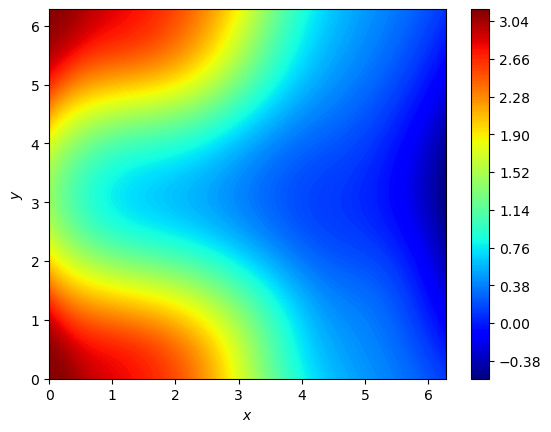

In [5]:
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.contourf(x1,x2,y,200,cmap='jet')
plt.colorbar()
plt.show()